<a href="https://colab.research.google.com/github/Aqeedathussain/Robotics-and-AI-Portfolio/blob/main/Grasp_point_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grasp Point Prediction — Cornell Grasping Dataset (ResNet-50)


## Step 1 — Import libraries

In [ ]:
# import sys
# !{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [ ]:
# import sys
# # Uninstall existing packages to ensure a clean state
# !{sys.executable} -m pip uninstall -y torch torchvision torchaudio
# # Reinstall PyTorch and related packages
# !{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [ ]:
import os
import glob
import math
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## Step 2 — Settings

In [ ]:
IMG_SIZE   = 224      # size of the image fed to the ResNet50
CROP       = 480      # center square crop taken from the 640x480 image
BATCH      = 32
EPOCHS     = 40
LR         = 1e-4
VAL_SPLIT  = 0.10
SEED       = 42

# Importing dataset from Google Drive
DATA_ROOT  = "/content/drive/MyDrive/Grasp_point_prediction_dataset"
DRIVE_DIR  = "/content/drive/MyDrive/grasp_project"   # trained model will be saved here
CKPT       = DRIVE_DIR + "/resnet50_grasp_best.pth"

# as model is pretrained so mean and std should be according to that
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Step 3 — Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_DIR, exist_ok=True)
print("Model will be saved to:", CKPT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model will be saved to: /content/drive/MyDrive/grasp_project/resnet50_grasp_best.pth


## Step 4 — Use the dataset from Google Drive

In [ ]:
# find all RGB images from drive folder
rgb_files = sorted(glob.glob(DATA_ROOT + "/**/pcd*r.png", recursive=True))

print("Looking in:", DATA_ROOT)
print("Total images found:", len(rgb_files))

if len(rgb_files) == 0:
    print("\nNo images found. Check that DATA_ROOT points to the right folder.")
    print("Folders currently inside your Drive root:")
    for name in sorted(os.listdir("/content/drive/MyDrive")):
        print("  ", name)
    raise SystemExit("Fix DATA_ROOT in Step 3, then run again.")

Looking in: /content/drive/MyDrive/Grasp_point_prediction_dataset
Total images found: 896


## Step 5 — Read grasp label files

Each image `pcdXXXXr.png` has a file `pcdXXXXcpos.txt` with the good grasps.
Every 4 lines = one rectangle (4 corner points).

In [ ]:
def read_grasps(txt_path):
    rects = []
    if not os.path.exists(txt_path):
        return rects
    points = []
    for line in open(txt_path):
        parts = line.split()
        if len(parts) != 2:
            continue
        try:
            x = float(parts[0])
            y = float(parts[1])
        except ValueError:
            continue
        points.append([x, y])
        if len(points) == 4:
            rect = np.array(points, dtype=np.float32)
            if not np.isnan(rect).any():   # skip broken rectangles
                rects.append(rect)
            points = []
    return rects

print("Grasps in first image:", len(read_grasps(rgb_files[0].replace("r.png", "cpos.txt"))))

Grasps in first image: 4


## Step 6 — Convert rectangle to / from grasp

A grasp = (x, y, angle, width, height). We convert the 4 corners into this,
and back. The angle repeats every 180°, so later we learn cos(2·angle) and
sin(2·angle) instead of the angle directly.

In [ ]:
def rect_to_grasp(corners):
    center = corners.mean(axis=0)
    edge1 = corners[1] - corners[0]
    edge2 = corners[2] - corners[1]
    angle = math.atan2(edge1[1], edge1[0])
    width = float(np.linalg.norm(edge1))
    height = float(np.linalg.norm(edge2))
    angle = (angle + math.pi/2) % math.pi - math.pi/2
    return np.array([center[0], center[1], angle, width, height], dtype=np.float32)

def grasp_to_rect(x, y, angle, width, height):
    c = math.cos(angle)
    s = math.sin(angle)
    dx = width / 2
    dy = height / 2
    box = np.array([[-dx, -dy], [dx, -dy], [dx, dy], [-dx, dy]], dtype=np.float32)
    R = np.array([[c, -s], [s, c]], dtype=np.float32)
    return box.dot(R.T) + np.array([x, y], dtype=np.float32)

def encode(grasp):
    x, y, a, w, h = grasp
    return torch.tensor([x/IMG_SIZE, y/IMG_SIZE, math.cos(2*a), math.sin(2*a),
                         w/IMG_SIZE, h/IMG_SIZE], dtype=torch.float32)

def decode(vec):
    x, y, c2, s2, w, h = [float(v) for v in vec]
    a = 0.5 * math.atan2(s2, c2)
    return np.array([x*IMG_SIZE, y*IMG_SIZE, a, w*IMG_SIZE, h*IMG_SIZE], dtype=np.float32)

## Step 7 — Build the Dataset

`prepare_image` loads one image, does simple augmentation (random rotate + flip)
during training, crops the center, resizes to 224, and returns the image plus the
grasps in the new coordinates.

In [ ]:
def prepare_image(path, augment):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    grasps = read_grasps(path.replace("r.png", "cpos.txt"))
    H, W = img.shape[:2]
    cx, cy = W/2, H/2

    # simple augmentation: rotate and flip
    if augment:
        angle = random.uniform(-30, 30)
        flip = random.random() < 0.5
    else:
        angle = 0.0
        flip = False

    M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    img = cv2.warpAffine(img, M, (W, H), borderMode=cv2.BORDER_REPLICATE)

    new_grasps = []
    for r in grasps:
        ones = np.ones((4, 1), dtype=np.float32)
        r2 = np.hstack([r, ones]).dot(M.T).astype(np.float32)
        new_grasps.append(r2)
    grasps = new_grasps

    if flip:
        img = img[:, ::-1, :].copy()
        grasps = [np.stack([W - 1 - r[:, 0], r[:, 1]], axis=1) for r in grasps]

    # center crop then resize to 224
    x0 = int(cx - CROP/2)
    y0 = int(cy - CROP/2)
    x0 = max(0, min(x0, W - CROP))
    y0 = max(0, min(y0, H - CROP))
    img = img[y0:y0+CROP, x0:x0+CROP]
    scale = IMG_SIZE / CROP
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    final = []
    for r in grasps:
        r = (r - np.array([x0, y0], dtype=np.float32)) * scale
        if r[:, 0].min() >= 0 and r[:, 0].max() < IMG_SIZE and \
           r[:, 1].min() >= 0 and r[:, 1].max() < IMG_SIZE:
            final.append(rect_to_grasp(r))

    # if augmentation pushed all grasps out of view, retry without augmentation
    if augment and len(final) == 0:
        return prepare_image(path, augment=False)

    tensor = img.astype(np.float32) / 255.0
    tensor = (tensor - MEAN) / STD
    tensor = torch.from_numpy(tensor.transpose(2, 0, 1))
    return tensor, final


class GraspDataset(Dataset):
    def __init__(self, files, augment):
        self.files = files
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        image, grasps = prepare_image(self.files[i], self.augment)
        # some images have all grasps outside the crop -> pick another image
        tries = 0
        while len(grasps) == 0 and tries < 20:
            i = random.randrange(len(self.files))
            image, grasps = prepare_image(self.files[i], self.augment)
            tries += 1
        if self.augment:
            g = grasps[random.randrange(len(grasps))]
        else:
            g = grasps[0]
        return image, encode(g)

print("Dataset ready")

Dataset ready


## Step 8 — Train / validation split

In [ ]:
files = sorted(rgb_files)
random.Random(SEED).shuffle(files)
n_val = int(len(files) * VAL_SPLIT)
val_files = files[:n_val]
train_files = files[n_val:]
print("Training images:", len(train_files))
print("Validation images:", len(val_files))

train_data = GraspDataset(train_files, augment=True)
val_data   = GraspDataset(val_files,   augment=False)

train_loader = DataLoader(train_data, batch_size=BATCH, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data,   batch_size=BATCH, shuffle=False, num_workers=2)

Training images: 807
Validation images: 89


## Step 9 — Show a few samples

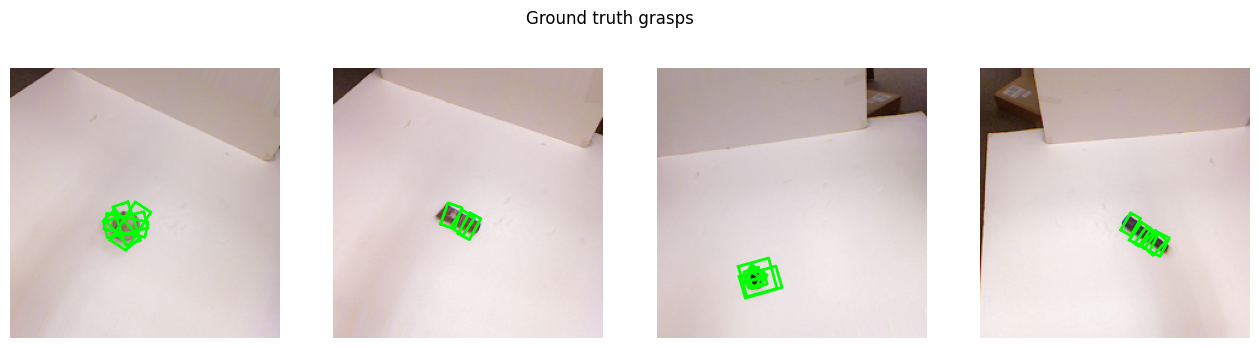

In [ ]:
def show_image(ax, tensor):
    img = tensor.numpy().transpose(1, 2, 0) * STD + MEAN
    ax.imshow(np.clip(img, 0, 1))
    ax.axis("off")

def draw_grasp(ax, grasp, color="lime"):
    x, y, a, w, h = grasp
    r = grasp_to_rect(x, y, a, w, h)
    r = np.vstack([r, r[0]])
    ax.plot(r[:, 0], r[:, 1], color=color, linewidth=2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax in axes:
    image, grasps = prepare_image(random.choice(train_files), augment=True)
    show_image(ax, image)
    for g in grasps:
        draw_grasp(ax, g)
plt.suptitle("Ground truth grasps")
plt.show()

## Step 10 — Build the ResNet-50 model

In [ ]:
class GraspModel(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = resnet50(weights=weights)
        n = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(n, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 6),
        )

    def forward(self, x):
        out = self.backbone(x)

        angle = out[:, 2:4]
        angle = angle / (angle.norm(dim=1, keepdim=True) + 1e-6)
        return torch.cat([out[:, :2], angle, out[:, 4:]], dim=1)

model = GraspModel(pretrained=True).to(device)
print("Model ready")

Model ready


## Step 11 — Accuracy metric (Cornell rule)

A predicted grasp is **correct** if, compared to any true grasp:
the angle difference is under **30°** and the rectangle overlap (IoU) is over **0.25**.

In [ ]:
def make_polygon(g):
    return Polygon(grasp_to_rect(g[0], g[1], g[2], g[3], g[4]))

def iou(g1, g2):
    p1 = make_polygon(g1)
    p2 = make_polygon(g2)
    if not p1.is_valid or not p2.is_valid:
        return 0.0
    inter = p1.intersection(p2).area
    union = p1.area + p2.area - inter
    return inter / union if union > 0 else 0.0

def angle_gap(a, b):
    d = abs(a - b) % math.pi
    return min(d, math.pi - d)

def is_correct(pred, true_grasps):
    for g in true_grasps:
        if angle_gap(pred[2], g[2]) < math.radians(30) and iou(pred, g) > 0.25:
            return True
    return False

## Step 12 — Loss and optimizer

In [ ]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def check_accuracy():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for path in val_files:
            image, grasps = prepare_image(path, augment=False)
            if len(grasps) == 0:
                continue
            out = model(image.unsqueeze(0).to(device)).cpu()[0]
            pred = decode(out)
            if is_correct(pred, grasps):
                correct += 1
            total += 1
    return correct / max(total, 1)

## Step 13 — Train the model

In [ ]:
best_acc = 0.0
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        out = model(images)
        loss = loss_fn(out, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    acc = check_accuracy()
    history.append((epoch, train_loss, acc))

    saved = ""
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), CKPT)
        saved = "  (saved)"
    print("Epoch %d/%d  loss=%.4f  val_acc=%.1f%%%s"
          % (epoch, EPOCHS, train_loss, acc*100, saved))

print("Best validation accuracy: %.1f%%" % (best_acc*100))

Epoch 1/40  loss=0.3455  val_acc=12.5%  (saved)
Epoch 2/40  loss=0.1990  val_acc=12.5%
Epoch 3/40  loss=0.1752  val_acc=12.5%
Epoch 4/40  loss=0.1432  val_acc=19.3%  (saved)
Epoch 5/40  loss=0.1336  val_acc=34.1%  (saved)
Epoch 6/40  loss=0.1317  val_acc=25.0%
Epoch 7/40  loss=0.1110  val_acc=19.3%
Epoch 8/40  loss=0.1019  val_acc=33.0%
Epoch 9/40  loss=0.1218  val_acc=30.7%
Epoch 10/40  loss=0.1012  val_acc=39.8%  (saved)
Epoch 11/40  loss=0.1086  val_acc=39.8%
Epoch 12/40  loss=0.0977  val_acc=52.3%  (saved)
Epoch 13/40  loss=0.1034  val_acc=45.5%
Epoch 14/40  loss=0.1012  val_acc=44.3%
Epoch 15/40  loss=0.0941  val_acc=45.5%
Epoch 16/40  loss=0.0948  val_acc=39.8%
Epoch 17/40  loss=0.0970  val_acc=43.2%
Epoch 18/40  loss=0.0933  val_acc=42.0%
Epoch 19/40  loss=0.0951  val_acc=40.9%
Epoch 20/40  loss=0.1067  val_acc=44.3%
Epoch 21/40  loss=0.1003  val_acc=46.6%
Epoch 22/40  loss=0.1035  val_acc=39.8%
Epoch 23/40  loss=0.1102  val_acc=43.2%
Epoch 24/40  loss=0.1083  val_acc=33.0%
Epoc

## Step 14 — Training graph

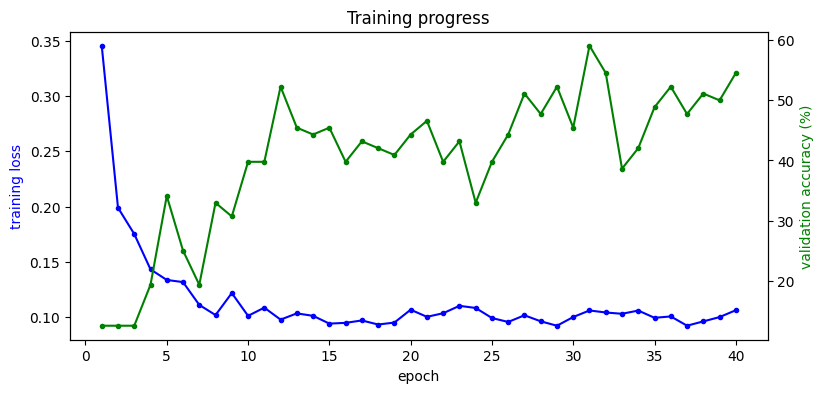

In [ ]:
epochs = [h[0] for h in history]
losses = [h[1] for h in history]
accs   = [h[2]*100 for h in history]

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(epochs, losses, "b-o", markersize=3)
ax1.set_xlabel("epoch")
ax1.set_ylabel("training loss", color="b")
ax2 = ax1.twinx()
ax2.plot(epochs, accs, "g-o", markersize=3)
ax2.set_ylabel("validation accuracy (%)", color="g")
plt.title("Training progress")
plt.show()

## Step 15 — Test on validation images

/tmp/ipykernel_2788/1521963893.py:26: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  x, y, c2, s2, w, h = [float(v) for v in vec]


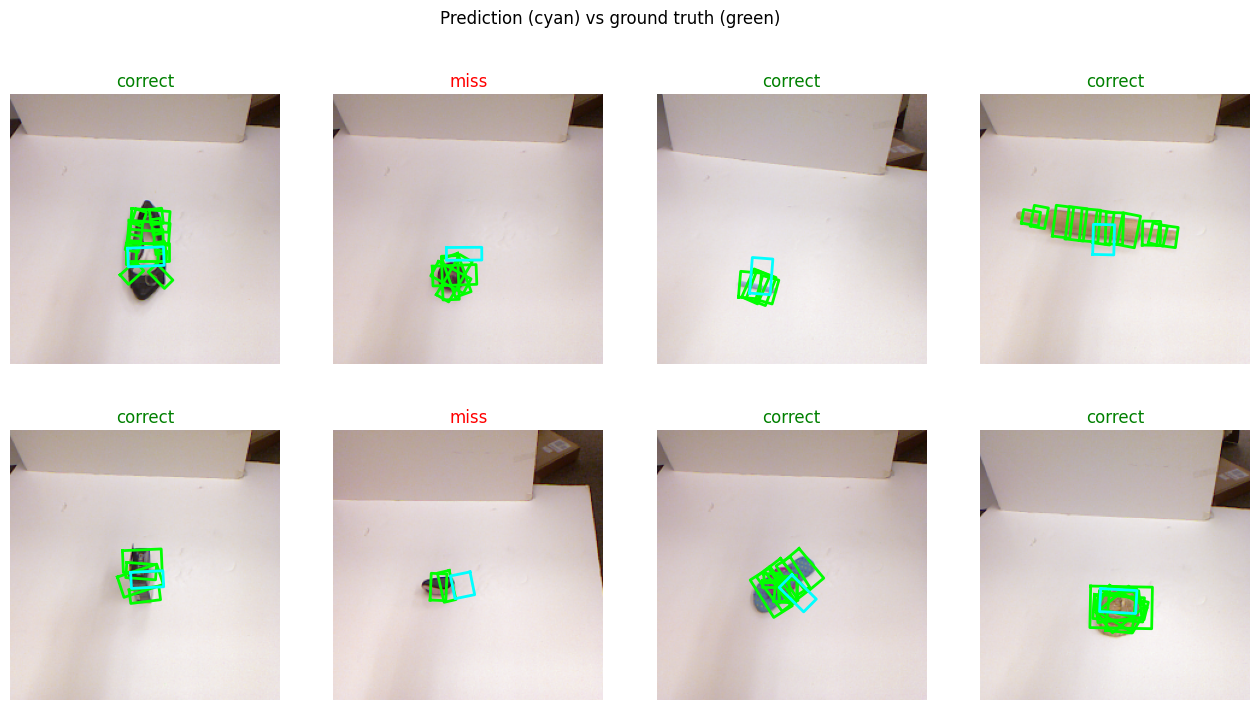

In [ ]:
model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax in axes.ravel():
    path = random.choice(val_files)
    image, grasps = prepare_image(path, augment=False)
    out = model(image.unsqueeze(0).to(device)).cpu()[0]
    pred = decode(out)
    show_image(ax, image)
    for g in grasps:
        draw_grasp(ax, g, color="lime")
    draw_grasp(ax, pred, color="cyan")
    ok = is_correct(pred, grasps)
    ax.set_title("correct" if ok else "miss", color="green" if ok else "red")
plt.suptitle("Prediction (cyan) vs ground truth (green)")
plt.show()

## Step 16 — Professional GUI (Gradio)

Upload an image and see the predicted grasp. Gradio prints a public link you can
open on any device.

In [ ]:
import gradio as gr
from PIL import Image

model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()

def predict(pil_image):
    if pil_image is None:
        return None, "Please upload an image."
    img = np.array(pil_image.convert("RGB"))
    H, W = img.shape[:2]
    side = min(H, W)
    y0 = (H - side) // 2
    x0 = (W - side) // 2
    img = img[y0:y0+side, x0:x0+side]
    small = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    tensor = small.astype(np.float32) / 255.0
    tensor = (tensor - MEAN) / STD
    tensor = torch.from_numpy(tensor.transpose(2, 0, 1)).unsqueeze(0)

    with torch.no_grad():
        out = model(tensor.to(device)).cpu()[0]
    g = decode(out)
    r = grasp_to_rect(g[0], g[1], g[2], g[3], g[4]).astype(int)

    view = small.copy()
    cv2.line(view, tuple(r[0]), tuple(r[1]), (255, 140, 0), 3)
    cv2.line(view, tuple(r[1]), tuple(r[2]), (0, 90, 255), 3)
    cv2.line(view, tuple(r[2]), tuple(r[3]), (255, 140, 0), 3)
    cv2.line(view, tuple(r[3]), tuple(r[0]), (0, 90, 255), 3)
    cv2.circle(view, (int(g[0]), int(g[1])), 5, (255, 0, 0), -1)
    view = cv2.resize(view, (448, 448), interpolation=cv2.INTER_NEAREST)

    text = ("### Predicted Grasp\n"
            "- Center (x, y): (%.0f, %.0f)\n"
            "- Angle: %.1f degrees\n"
            "- Opening width: %.0f\n"
            "- Plate length: %.0f\n\n"
            "Blue edges = gripper plates, orange = opening, red dot = center."
            % (g[0], g[1], math.degrees(g[2]), g[3], g[4]))
    return Image.fromarray(view), text

with gr.Blocks(theme=gr.themes.Soft(primary_hue="indigo"),
               title="Grasp Point Predictor") as demo:
    gr.Markdown("<h1 style='text-align:center'>Robotic Grasp Point Predictor</h1>"
                "<p style='text-align:center;color:#666'>ResNet-50 on the Cornell "
                "Grasping Dataset</p>")
    with gr.Row():
        with gr.Column():
            inp = gr.Image(type="pil", label="Object image", height=360)
            btn = gr.Button("Predict Grasp", variant="primary", size="lg")
        with gr.Column():
            out_img = gr.Image(label="Predicted grasp", height=360)
            out_txt = gr.Markdown()
    btn.click(predict, inputs=inp, outputs=[out_img, out_txt])
    inp.upload(predict, inputs=inp, outputs=[out_img, out_txt])

demo.launch(share=True)

/tmp/ipykernel_2788/1596426204.py:44: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="indigo"),


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d99f02cda732e0af16.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Step 17— Using it on a real robot arm

The GUI gives the grasp in image pixels. To move a real arm:

1. Use the depth image and camera intrinsics to turn the pixel center (x, y) into a
   3-D point (X, Y, Z) in the camera frame.
2. Apply your hand-eye calibration to convert that point into the robot base frame.
3. Use the predicted angle as the gripper rotation, and convert the pixel width into a
   real gripper opening using the depth.
4. Send the final pose to your motion planner (for example MoveIt).

To get even higher accuracy later: train for more epochs, add depth as an extra input
channel (RGD), or try the GR-ConvNet model.